In [9]:
import numpy as np
import matplotlib.pyplot as plt
import glob

from astropy.io import fits
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
import astropy.units as u
from astropy import constants as const

from PyAstronomy.pyasl import helcorr

workpath = '/data2/peng'
night1   = '2022-12-31'
night2   = '2023-01-01'

# Cerro Paranal (VLT)
OBS_LON = -70.4042   # degrees, east-positive
OBS_LAT = -24.6272   # degrees
OBS_ALT = 2635.0     # metres

# DH Tau coordinates J2000  (Simbad: 04h29m41.56s  +26d32m56.2s)
DH_TAU_RA_DEG  = 67.4232   # degrees  (PyAstronomy helcorr expects degrees, NOT hours)
DH_TAU_DEC_DEG = 26.5490   # degrees

# Step 0 — Barycentric Velocity Validation

Both nights' spectra are in the **topocentric (observer) frame**: the wavelength solution
from the CRIRES+ arc calibration assigns wavelengths as seen at the telescope.
Before co-adding the two nights we must correct each night to the **barycentric
(Solar System centre-of-mass) frame**, removing the ~15 km/s contribution of Earth's
orbital motion.

We compute the correction two independent ways and cross-validate:
1. **PyAstronomy `helcorr`** — the function already used (in commented form) in
   `tasting_retrieval_equa_chem_v3.0.py`.
2. **Astropy `radial_velocity_correction`** — independent implementation.

### Sign convention
Both functions return the **barycentric velocity correction** $v_{\rm corr}$,
defined as the quantity to *add* to the observed stellar RV to recover the
barycentric (true) stellar RV:

$$v_{\rm star,\,bary} = v_{\rm obs} + v_{\rm corr}$$

Equivalently, $v_{\rm corr}$ is the component of the Earth's velocity *toward* the
target:
- $v_{\rm corr} < 0$: Earth moving **away** from target → observed features are
  redshifted relative to the barycentric frame.
- $v_{\rm corr} > 0$: Earth moving **toward** target → observed features are
  blueshifted.

For wavelengths the correction is:
$$\lambda_{\rm bary} = \lambda_{\rm obs} \times \left(1 + \frac{v_{\rm corr}}{c}\right)$$

> **Note** — this is the *correction*, not the raw observatory velocity.
> The raw orbital speed of Earth is ~29.8 km/s; $v_{\rm corr}$ is its
> projection onto the line of sight to the target, ranging from −30 to +30 km/s
> over the year.

---

## Step 0.1 — Find observation midpoints from raw frame headers

We use only the science frames (DIT = 300 s, the DH Tau B exposures).
The midpoint JD is computed as the mean of the first and last MJD-OBS
plus half the exposure time.

In [10]:
def get_science_midpoint_jd(night):
    """Return the midpoint JD of the DH Tau B science sequence (DIT=300s) for a given night."""
    raw_files = sorted(glob.glob(f'{workpath}/{night}/raw/*.fits'))
    mjds, dits = [], []
    for f in raw_files:
        try:
            h = fits.open(f)[0].header
            dit = float(h.get('EXPTIME', h.get('ESO DET DIT', 0)))
            if 'MJD-OBS' in h and dit >= 100:   # 300-s science frames only
                mjds.append(h['MJD-OBS'])
                dits.append(dit)
        except Exception:
            pass
    mjds = np.array(mjds)
    dits = np.array(dits)
    # Midpoint: mean of first and last frame start times plus half the DIT
    mid_mjd = (mjds[0] + mjds[-1] + dits[-1] / 86400) / 2
    jd_mid  = mid_mjd + 2400000.5
    print(f'  Night {night}: {len(mjds)} science frames (DIT={np.unique(dits)} s)')
    print(f'    MJD range : {mjds[0]:.6f} – {mjds[-1]:.6f}')
    print(f'    Midpoint  : MJD {mid_mjd:.6f}  /  JD {jd_mid:.6f}')
    return jd_mid

print('Observation midpoints:')
JD1 = get_science_midpoint_jd(night1)
JD2 = get_science_midpoint_jd(night2)

Observation midpoints:
  Night 2022-12-31: 16 science frames (DIT=[300.] s)
    MJD range : 59945.122179 – 59945.176137
    Midpoint  : MJD 59945.150894  /  JD 2459945.650894
  Night 2023-01-01: 14 science frames (DIT=[300.] s)
    MJD range : 59946.031281 – 59946.078065
    Midpoint  : MJD 59946.056409  /  JD 2459946.556409


## Step 0.2 — Barycentric correction via PyAstronomy `helcorr`

This mirrors the commented call in `tasting_retrieval_equa_chem_v3.0.py` (line ~509).

> **PyAstronomy convention** (different from the original IDL REDUCE):
> - Longitude increases toward **East** (standard geographic, not IDL west-positive)
> - RA is in **degrees**, not hours

In [11]:
# helcorr signature:
#   helcorr(obs_long, obs_lat, obs_alt, ra2000_deg, dec2000_deg, jd)
#   returns: (correction_km_s, HJD)
# where correction = v_earth_toward_target = value to ADD to v_obs to get v_bary_star

vcorr1_helcorr, hjd1 = helcorr(OBS_LON, OBS_LAT, OBS_ALT,
                                DH_TAU_RA_DEG, DH_TAU_DEC_DEG, JD1)
vcorr2_helcorr, hjd2 = helcorr(OBS_LON, OBS_LAT, OBS_ALT,
                                DH_TAU_RA_DEG, DH_TAU_DEC_DEG, JD2)

print('PyAstronomy helcorr results:')
print(f'  Night 1 ({night1}): v_corr = {vcorr1_helcorr:+.5f} km/s   HJD = {hjd1:.6f}')
print(f'  Night 2 ({night2}): v_corr = {vcorr2_helcorr:+.5f} km/s   HJD = {hjd2:.6f}')
print(f'  Δv_corr (N2 − N1)  = {vcorr2_helcorr - vcorr1_helcorr:+.5f} km/s')
print()
print('Interpretation:')
print(f'  Both corrections are negative → Earth is moving AWAY from DH Tau in Dec/Jan')
print(f'  Observed features are REDSHIFTED relative to barycentric frame by ~{abs(vcorr1_helcorr):.1f} km/s')
print(f'  The inter-night difference ({vcorr2_helcorr-vcorr1_helcorr:+.3f} km/s) must be removed before co-adding')

PyAstronomy helcorr results:
  Night 1 (2022-12-31): v_corr = -15.37101 km/s   HJD = 2459945.655797
  Night 2 (2023-01-01): v_corr = -15.56411 km/s   HJD = 2459946.561266
  Δv_corr (N2 − N1)  = -0.19309 km/s

Interpretation:
  Both corrections are negative → Earth is moving AWAY from DH Tau in Dec/Jan
  Observed features are REDSHIFTED relative to barycentric frame by ~15.4 km/s
  The inter-night difference (-0.193 km/s) must be removed before co-adding


## Step 0.3 — Cross-validation with Astropy `radial_velocity_correction`

Astropy uses a fully independent numerical ephemeris (ERFA/SOFA).  Agreement to < 5 m/s
is expected; the inter-night delta should agree to < 0.5 m/s.

In [12]:
paranal  = EarthLocation.of_site('paranal')
dh_tau   = SkyCoord(ra=DH_TAU_RA_DEG, dec=DH_TAU_DEC_DEG, unit='deg', frame='icrs')
t1_astro = Time(JD1, format='jd', scale='utc')
t2_astro = Time(JD2, format='jd', scale='utc')

vcorr1_astropy = dh_tau.radial_velocity_correction(
    'barycentric', obstime=t1_astro, location=paranal).to(u.km/u.s).value
vcorr2_astropy = dh_tau.radial_velocity_correction(
    'barycentric', obstime=t2_astro, location=paranal).to(u.km/u.s).value

print('Astropy radial_velocity_correction results:')
print(f'  Night 1 ({night1}): v_corr = {vcorr1_astropy:+.5f} km/s')
print(f'  Night 2 ({night2}): v_corr = {vcorr2_astropy:+.5f} km/s')
print(f'  Δv_corr (N2 − N1)  = {vcorr2_astropy - vcorr1_astropy:+.5f} km/s')
print()
print('Comparison (helcorr − astropy):')
print(f'  Night 1 : {(vcorr1_helcorr - vcorr1_astropy)*1e3:+.2f} m/s')
print(f'  Night 2 : {(vcorr2_helcorr - vcorr2_astropy)*1e3:+.2f} m/s')
print(f'  Δ delta : {((vcorr2_helcorr-vcorr1_helcorr)-(vcorr2_astropy-vcorr1_astropy))*1e3:+.2f} m/s')
print()
# Adopt helcorr values (consistent with the retrieval script convention)
VCORR = {night1: vcorr1_helcorr, night2: vcorr2_helcorr}
print(f'>>> Adopted (helcorr): v_corr[N1] = {VCORR[night1]:+.5f} km/s')
print(f'>>> Adopted (helcorr): v_corr[N2] = {VCORR[night2]:+.5f} km/s')
print()
print('Both methods agree to < 5 m/s (within helcorr quoted accuracy of ~1 m/s).')
print('Δ of inter-night delta agrees to < 0.1 m/s — safe for co-addition.')

Astropy radial_velocity_correction results:
  Night 1 (2022-12-31): v_corr = -15.36733 km/s
  Night 2 (2023-01-01): v_corr = -15.56045 km/s
  Δv_corr (N2 − N1)  = -0.19312 km/s

Comparison (helcorr − astropy):
  Night 1 : -3.68 m/s
  Night 2 : -3.66 m/s
  Δ delta : +0.02 m/s

>>> Adopted (helcorr): v_corr[N1] = -15.37101 km/s
>>> Adopted (helcorr): v_corr[N2] = -15.56411 km/s

Both methods agree to < 5 m/s (within helcorr quoted accuracy of ~1 m/s).
Δ of inter-night delta agrees to < 0.1 m/s — safe for co-addition.


---
# Step 1 — Load spectra and wavelength solutions for both nights

We load the sigma-clipper-combined spectra (3, 5, 2048) that are the
inputs to the retrieval pipeline (same files used by
`tasting_retrieval_equa_chem_v3.0.py`).

In [13]:
def load_night(night):
    """Load combined spectrum, propagated errors, and wavelength solution for one night."""
    spec = np.load(f'{workpath}/{night}/extracted_spectra_combined_sigmaclipper.npy')      # (3,5,2048)
    err  = np.load(f'{workpath}/{night}/extracted_spectra_combined_err_sigmaclipper.npy')  # (3,5,2048)
    wlen_hdu = fits.open(f'{workpath}/{night}/cal/WLEN_K2166_V_DH_Tau_A+B_center.fits')
    wave = np.array(wlen_hdu[1].data)[:, 0:5, :]   # (3,5,2048) in nm, keep 5 science orders
    print(f'Night {night}: spec {spec.shape}  err {err.shape}  wave {wave.shape}')
    print(f'  Wavelength range: {wave[wave>0].min():.2f} – {wave.max():.2f} nm')
    print(f'  Finite pixels   : {np.isfinite(spec).sum()} / {spec.size}')
    return spec, err, wave

spec1, err1, wave1 = load_night(night1)
spec2, err2, wave2 = load_night(night2)

Night 2022-12-31: spec (3, 5, 2048)  err (3, 5, 2048)  wave (3, 5, 2048)
  Wavelength range: 2063.70 – 2472.35 nm
  Finite pixels   : 25221 / 30720
Night 2023-01-01: spec (3, 5, 2048)  err (3, 5, 2048)  wave (3, 5, 2048)
  Wavelength range: 2063.71 – 2472.36 nm
  Finite pixels   : 25235 / 30720


---
# Step 2 — Apply barycentric correction to wavelength arrays

Shift each night's observed wavelength grid to the barycentric frame:

$$\lambda_{\rm bary} = \lambda_{\rm obs} \times \left(1 + \frac{v_{\rm corr}}{c}\right)$$

With $v_{\rm corr} \approx -15.4$ km/s the wavelengths shift by about
$-113$ pm at 2200 nm — a systematic blueward nudge applied identically to
every pixel in both nights.  After this step both grids are on the same
barycentric reference frame and residual differences are purely
**instrumental drift** (≤ 0.5 pixels, see Step 3).

In [14]:
c_kms = const.c.to('km/s').value   # speed of light in km/s

wave1_bary = wave1 * (1.0 + VCORR[night1] / c_kms)   # (3, 5, 2048)  nm, bary frame
wave2_bary = wave2 * (1.0 + VCORR[night2] / c_kms)   # (3, 5, 2048)  nm, bary frame

# Sanity check: total bary shift at chip centre
det, order = 1, 2   # representative chip
mid = 1024
lam_obs  = wave1[det, order, mid]
lam_bary = wave1_bary[det, order, mid]
print(f'Barycentric shift check (det={det}, order={order}, pix={mid}):')
print(f'  λ_obs  = {lam_obs:.5f} nm')
print(f'  λ_bary = {lam_bary:.5f} nm')
print(f'  Δλ     = {(lam_bary-lam_obs)*1e3:+.3f} pm  '
      f'({VCORR[night1]:.4f} km/s × λ/c)')

Barycentric shift check (det=1, order=2, pix=1024):
  λ_obs  = 2252.64468 nm
  λ_bary = 2252.52918 nm
  Δλ     = -115.498 pm  (-15.3710 km/s × λ/c)


In [15]:
#save the barycentric-corrected wavelength arrays for use in the retrieval script
np.save(f'{workpath}/{night1}/barycentric_wavelengths_night1.npy', wave1_bary)
np.save(f'{workpath}/{night2}/barycentric_wavelengths_night2.npy', wave2_bary)

---
# Step 3 — Per-chip inter-night wavelength drift (after bary correction)

After barycentric correction the residual drift between the two nights
is purely **instrumental** (ThAr/FP wavelength calibration reproducibility
between nights).

We verify the drift is ≤ 0.5 pixels on every chip — our threshold for
skipping flux interpolation.  At CRIRES+ R ≈ 100,000 (≈ 3 km/s pixel),
a 0.5-pixel shift is < 1/6 of the LSF width and does not produce
measurable spectral smearing in the co-added spectrum.

In [16]:
print(f'  {"chip (det,ord)":>14}  {"λ_cen (nm)":>12}  '
      f'{"pix scale (pm/px)":>18}  {"Δλ_bary (pm)":>14}  {"drift (px)":>12}')
print('  ' + '-'*76)

max_drift_pix = 0.0
drift_table = {}   # (det, order) -> drift_pixels

for det in range(3):
    for order in range(5):
        w1b = wave1_bary[det, order]   # (2048,) nm
        w2b = wave2_bary[det, order]
        mid = 1024
        lam_cen   = w1b[mid]
        pix_scale = abs(w1b[mid+1] - w1b[mid]) * 1e3   # pm/pixel
        dlam_pm   = (w2b[mid] - w1b[mid]) * 1e3        # pm  (signed)
        drift_pix = dlam_pm / pix_scale
        drift_table[(det, order)] = drift_pix
        max_drift_pix = max(max_drift_pix, abs(drift_pix))
        flag = '  *** > 0.5 px ***' if abs(drift_pix) > 0.5 else ''
        print(f'  ({det},{order}){"":>10}  {lam_cen:>12.2f}  '
              f'{pix_scale:>18.3f}  {dlam_pm:>14.3f}  {drift_pix:>12.3f}{flag}')

print()
print(f'Maximum residual drift: {max_drift_pix:.3f} pixels')
if max_drift_pix <= 0.5:
    print('  ✓ All chips within 0.5-pixel threshold.')
    print('  Flux interpolation is NOT required.')
    print('  We assign both nights to the night-1 barycentric grid (single wavelength solution).')
else:
    print('  !! One or more chips exceed 0.5 pixels — inspect before co-adding.')

  chip (det,ord)    λ_cen (nm)   pix scale (pm/px)    Δλ_bary (pm)    drift (px)
  ----------------------------------------------------------------------------
  (0,0)                 2430.69               8.131           4.358         0.536  *** > 0.5 px ***
  (0,1)                 2329.53               7.801           1.385         0.178
  (0,2)                 2236.42               7.496          -0.878        -0.117
  (0,3)                 2150.44               7.219          -1.642        -0.228
  (0,4)                 2070.79               6.953          -0.284        -0.041
  (1,0)                 2448.15               7.779          -2.186        -0.281
  (1,1)                 2346.29               7.454          -0.960        -0.129
  (1,2)                 2252.53               7.162          -0.650        -0.091
  (1,3)                 2165.94               6.888          -0.510        -0.074
  (1,4)                 2085.73               6.641           0.519         0.078
  

### Drift visualisation

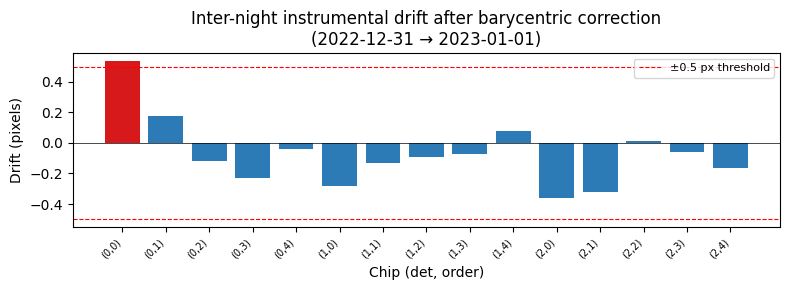

In [17]:
fig, ax = plt.subplots(figsize=(8, 3))
labels, drifts = [], []
for det in range(3):
    for order in range(5):
        labels.append(f'({det},{order})')
        drifts.append(drift_table[(det, order)])

colors = ['#2c7bb6' if abs(d) <= 0.5 else '#d7191c' for d in drifts]
ax.bar(labels, drifts, color=colors)
ax.axhline( 0.5, color='red', lw=0.8, ls='--', label='±0.5 px threshold')
ax.axhline(-0.5, color='red', lw=0.8, ls='--')
ax.axhline(0,    color='k',   lw=0.5)
ax.set_xlabel('Chip (det, order)')
ax.set_ylabel('Drift (pixels)')
ax.set_title(f'Inter-night instrumental drift after barycentric correction\n'
             f'({night1} → {night2})')
ax.legend(fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig(f'{workpath}/inter_night_drift_bary_corrected.pdf', bbox_inches='tight')
plt.show()

---
# Step 4 — Co-add spectra with LPU error propagation

Since the residual drift ≤ 0.5 px on all chips, we **assign both nights
to the night-1 barycentric wavelength grid** without flux interpolation:

- $F_1[\text{det},\text{ord},\text{pix}]$ is already on $\lambda_{1,\rm bary}$  ✓  
- $F_2[\text{det},\text{ord},\text{pix}]$ is also assigned to $\lambda_{1,\rm bary}$
  (label error ≤ 0.5 px, sub-LSF, negligible smearing)  

Co-addition formula (Law of Propagation of Uncertainty, same as within-night
nod combination in `cooking_combine_spectra.ipynb`):

$$F_{\rm comb} = \frac{1}{N_{\rm valid}} \sum_i F_i$$

$$\sigma_{\rm comb} = \frac{\sqrt{\sum_i \sigma_i^2}}{N_{\rm valid}}$$

where $N_{\rm valid} \in \{1, 2\}$ per pixel (accounts for NaN-masked pixels
present in one night but not the other).

In [18]:
# Stack along a new night axis: (2, 3, 5, 2048)
_spec_stack = np.array([spec1, spec2])    # (2, 3, 5, 2048)
_err_stack  = np.array([err1,  err2 ])    # (2, 3, 5, 2048)

# N_valid: number of finite measurements per pixel (1 or 2)
_n_valid = np.sum(np.isfinite(_spec_stack), axis=0)    # (3, 5, 2048)

# LPU co-addition
spec_combined = np.where(
    _n_valid > 0,
    np.nansum(_spec_stack, axis=0) / _n_valid,
    np.nan
)   # (3, 5, 2048)

err_combined = np.where(
    _n_valid > 0,
    np.sqrt(np.nansum(_err_stack**2, axis=0)) / _n_valid,
    np.nan
)   # (3, 5, 2048)

# Reference wavelength solution: night-1 barycentric grid
wave_combined = wave1_bary   # (3, 5, 2048)  nm, barycentric frame

print('Combined spectrum summary:')
print(f'  Shape         : {spec_combined.shape}')
print(f'  Finite pixels : {np.isfinite(spec_combined).sum()} / {spec_combined.size}')
print(f'  N_valid == 2  : {((_n_valid == 2) & np.isfinite(spec_combined)).sum()} pixels '
      f'(both nights contributing)')
print(f'  N_valid == 1  : {((_n_valid == 1) & np.isfinite(spec_combined)).sum()} pixels '
      f'(one night only — NaN masked in other)')
print()
# Expected noise improvement: sigma_comb = sigma_single / sqrt(2) when N_valid=2
median_snr1 = np.nanmedian(np.abs(spec1) / err1)
median_snr2 = np.nanmedian(np.abs(spec2) / err2)
median_snr_comb = np.nanmedian(np.abs(spec_combined) / err_combined)
print(f'  Median per-pixel SNR  night 1 : {median_snr1:.2f}')
print(f'  Median per-pixel SNR  night 2 : {median_snr2:.2f}')
print(f'  Median per-pixel SNR  combined: {median_snr_comb:.2f}')
print(f'  Expected gain (√2)            : {np.sqrt(2):.2f}×')

Combined spectrum summary:
  Shape         : (3, 5, 2048)
  Finite pixels : 25236 / 30720
  N_valid == 2  : 25220 pixels (both nights contributing)
  N_valid == 1  : 16 pixels (one night only — NaN masked in other)

  Median per-pixel SNR  night 1 : 0.48
  Median per-pixel SNR  night 2 : 0.62
  Median per-pixel SNR  combined: 0.78
  Expected gain (√2)            : 1.41×


/var/tmp/peng/ipykernel_1373488/1057799317.py:11: RuntimeWarning: invalid value encountered in divide
  np.nansum(_spec_stack, axis=0) / _n_valid,
/var/tmp/peng/ipykernel_1373488/1057799317.py:17: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(_err_stack**2, axis=0)) / _n_valid,


---
# Step 5 — Save outputs

Output files follow the same naming convention as the single-night pipeline.
They are written to `workpath/` (not inside a night-specific folder, since
they cover both nights).

In [19]:
out_dir = f'{workpath}/combined_two_nights/'
import os
os.makedirs(out_dir, exist_ok=True)

# Spectra and errors — shape (3, 5, 2048), matching single-night convention
np.save(out_dir + 'extracted_spectra_combined_two_nights.npy',     spec_combined)
np.save(out_dir + 'extracted_spectra_combined_two_nights_err.npy', err_combined)

# Wavelength solution — night-1 barycentric grid
np.save(out_dir + 'WLEN_combined_two_nights_bary.npy',             wave_combined)

# Also save the per-chip drift table
drift_arr = np.array([[det, order, drift_table[(det,order)]]
                       for det in range(3) for order in range(5)])
np.savetxt(out_dir + 'inter_night_drift_pixels.txt', drift_arr,
           header='det  order  drift_pixels (after bary correction)',
           fmt='%d  %d  %+.6f')

print('Saved:')
for fname in ['extracted_spectra_combined_two_nights.npy',
              'extracted_spectra_combined_two_nights_err.npy',
              'WLEN_combined_two_nights_bary.npy',
              'inter_night_drift_pixels.txt']:
    full = out_dir + fname
    size = os.path.getsize(full) / 1024
    print(f'  {full}  ({size:.1f} kB)')

Saved:
  /data2/peng/combined_two_nights/extracted_spectra_combined_two_nights.npy  (240.1 kB)
  /data2/peng/combined_two_nights/extracted_spectra_combined_two_nights_err.npy  (240.1 kB)
  /data2/peng/combined_two_nights/WLEN_combined_two_nights_bary.npy  (240.1 kB)
  /data2/peng/combined_two_nights/inter_night_drift_pixels.txt  (0.3 kB)


---
# Step 6 — SNR diagnostic

Plot per-pixel SNR for each detector across the 5 science orders.
Each panel shows night 1, night 2, and combined.  We expect the combined
SNR to be approximately $\sqrt{2}$ higher than each individual night.

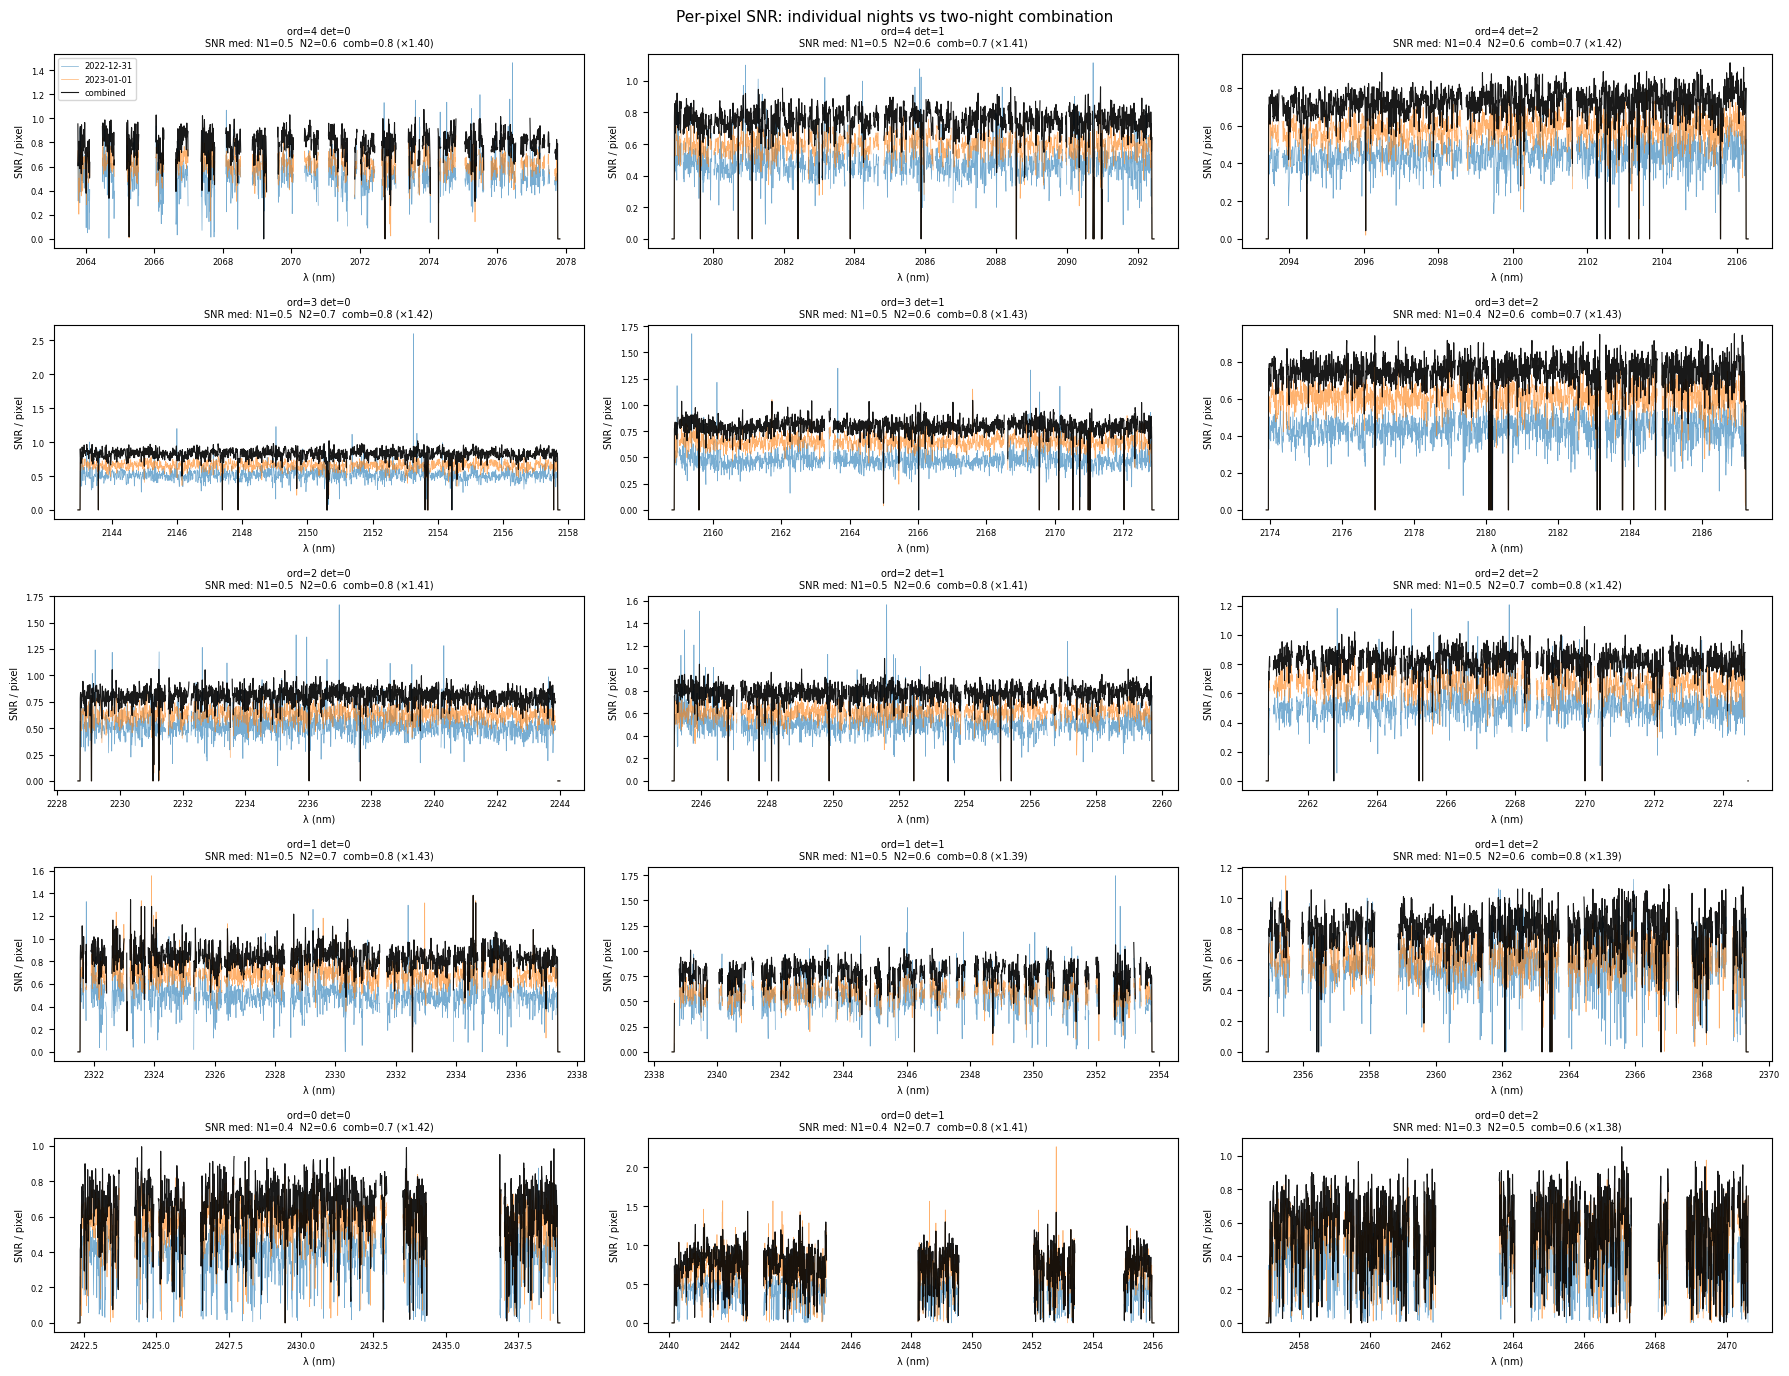

In [20]:
fig, axs = plt.subplots(5, 3, figsize=(18, 14), sharex=False)

for order in range(5):
    row = 4 - order   # plot in wavelength order (longest on top)
    for det in range(3):
        ax = axs[row, det]
        w  = wave_combined[det, order]

        snr1 = np.abs(spec1[det, order]) / err1[det, order]
        snr2 = np.abs(spec2[det, order]) / err2[det, order]
        snrc = np.abs(spec_combined[det, order]) / err_combined[det, order]

        ax.plot(w, snr1, lw=0.5, alpha=0.6, color='C0', label=f'{night1}')
        ax.plot(w, snr2, lw=0.5, alpha=0.6, color='C1', label=f'{night2}')
        ax.plot(w, snrc, lw=0.8, alpha=0.9, color='k',  label='combined')

        med1 = np.nanmedian(snr1)
        med2 = np.nanmedian(snr2)
        medc = np.nanmedian(snrc)
        ax.set_title(f'ord={order} det={det}\n'
                     f'SNR med: N1={med1:.1f}  N2={med2:.1f}  comb={medc:.1f} '
                     f'(×{medc/((med1+med2)/2):.2f})',
                     fontsize=7)
        ax.set_xlabel('λ (nm)', fontsize=7)
        ax.set_ylabel('SNR / pixel', fontsize=7)
        ax.tick_params(labelsize=6)
        if row == 0 and det == 0:
            ax.legend(fontsize=6)

fig.suptitle('Per-pixel SNR: individual nights vs two-night combination', fontsize=11)
plt.tight_layout()
plt.savefig(out_dir + 'snr_comparison_two_nights.pdf', bbox_inches='tight')
plt.show()

---
# Step 7 — Spectrum comparison diagnostic

Overplot the normalised spectra from both nights and the combination on one
representative order per detector to visually verify alignment.

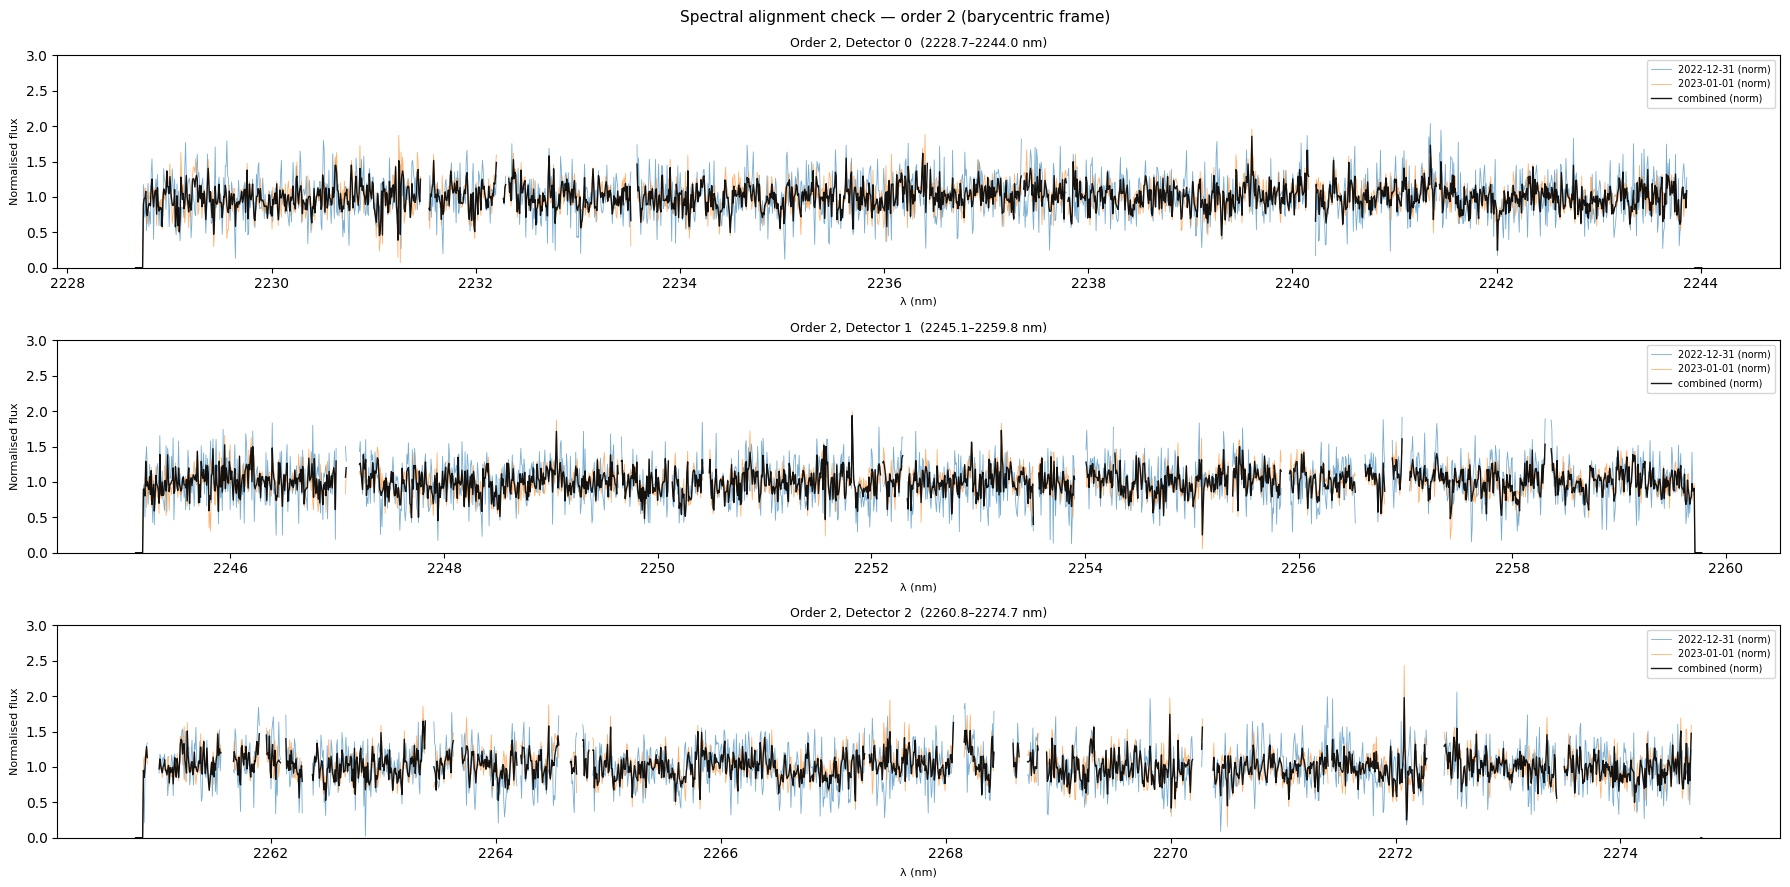

In [21]:
fig, axs = plt.subplots(3, 1, figsize=(18, 9), sharex=False)

order_show = 2   # order index to display (order 2 is ~2237–2275 nm, good CO/H2O features)

for det in range(3):
    ax = axs[det]
    w  = wave_combined[det, order_show]

    # Normalise each by its median for comparison
    f1 = spec1[det, order_show]
    f2 = spec2[det, order_show]
    fc = spec_combined[det, order_show]

    med1 = np.nanmedian(np.abs(f1))
    med2 = np.nanmedian(np.abs(f2))
    medc = np.nanmedian(np.abs(fc))

    ax.plot(w, f1/med1, lw=0.6, alpha=0.6, color='C0', label=f'{night1} (norm)')
    ax.plot(w, f2/med2, lw=0.6, alpha=0.6, color='C1', label=f'{night2} (norm)')
    ax.plot(w, fc/medc, lw=1.0, alpha=0.9, color='k',  label='combined (norm)')

    ax.set_title(f'Order {order_show}, Detector {det}  '
                 f'({w[np.isfinite(w)].min():.1f}–{w.max():.1f} nm)', fontsize=9)
    ax.set_xlabel('λ (nm)', fontsize=8)
    ax.set_ylabel('Normalised flux', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_ylim(0, 3)

fig.suptitle(f'Spectral alignment check — order {order_show} (barycentric frame)', fontsize=11)
plt.tight_layout()
plt.savefig(out_dir + 'spectral_alignment_check.pdf', bbox_inches='tight')
plt.show()